In [1]:
from scripts.csv_continue_to_ds_discreet import csv_continue_to_ds_discreet
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from scripts.evaluate_model import evaluate_predictions

In [2]:
X, y = csv_continue_to_ds_discreet()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [4]:
ratio = sum(y_train == 0) / sum(y_train == 1)

model_1 = Pipeline([
  ('xgboost', XGBClassifier(random_state=0, scale_pos_weight=ratio))
])

In [5]:
params = {
  'xgboost__n_estimators': [50, 100, 150],
  'xgboost__learning_rate': [0.01, 0.02, 0.05],
  'xgboost__max_depth': [5, 10]
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(model_1, param_grid=params, cv=cv_stratified, scoring='roc_auc', n_jobs=-1)

In [6]:
gs.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgboost__learning_rate': [0.01, 0.02, ...], 'xgboost__max_depth': [5, 10], 'xgboost__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [7]:
(f'best_score: {gs.best_score_}; best_params: {gs.best_params_}')

"best_score: 0.794520920266845; best_params: {'xgboost__learning_rate': 0.01, 'xgboost__max_depth': 5, 'xgboost__n_estimators': 150}"

In [8]:
def evaluate_on_train_test(model, X_train, y_train, X_test, y_test):
    print(f"Evaluating train data")
    train_predictions = model.predict(X_train)
    train_probas = model.predict_proba(X_train)
    evaluate_predictions(train_predictions, y_train, train_probas[:, 1])
    
    print("Evaluating on test data")
    
    test_predictions = model.predict(X_test)
    test_probas = model.predict_proba(X_test)
    evaluate_predictions(test_predictions, y_test, test_probas[:, 1])


Evaluating train data


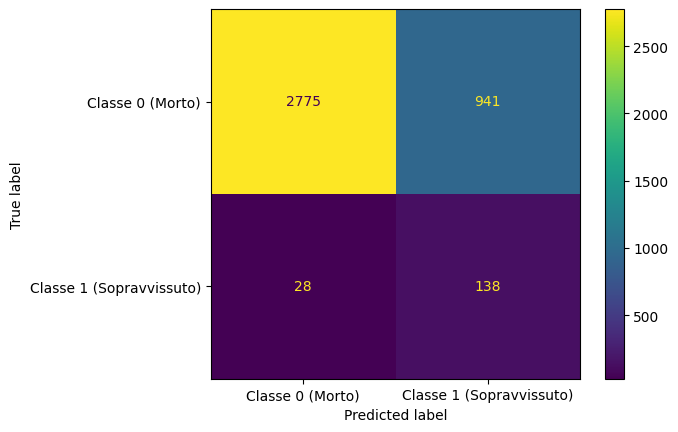

Percentuale di veri negativi: 74.68%
Percentuale di veri positivi: 83.13%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.99      0.75      0.85      3716
Classe 1 (Sopravvissuto)       0.13      0.83      0.22       166

                accuracy                           0.75      3882
               macro avg       0.56      0.79      0.54      3882
            weighted avg       0.95      0.75      0.82      3882

[[2775  941]
 [  28  138]]


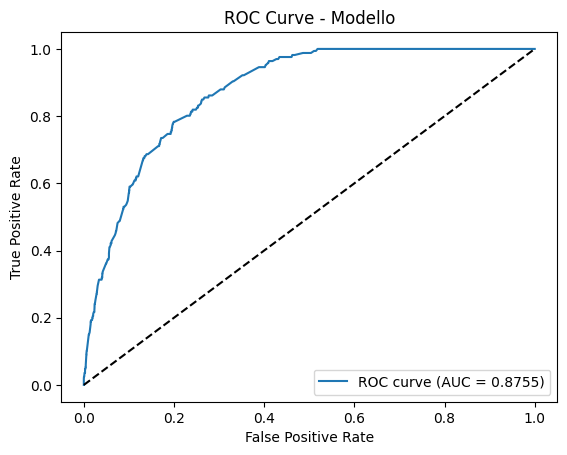

Evaluating on test data


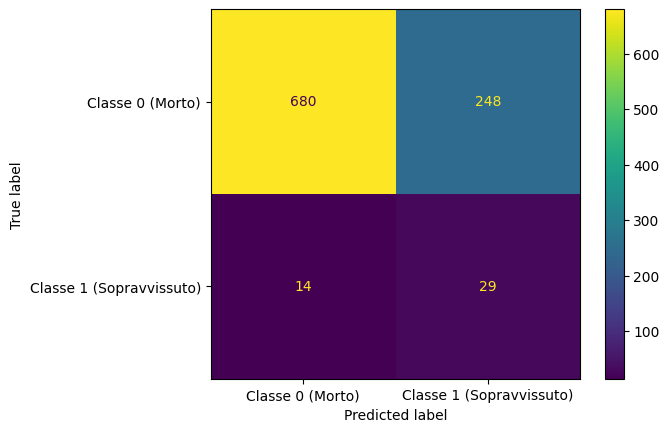

Percentuale di veri negativi: 73.28%
Percentuale di veri positivi: 67.44%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.98      0.73      0.84       928
Classe 1 (Sopravvissuto)       0.10      0.67      0.18        43

                accuracy                           0.73       971
               macro avg       0.54      0.70      0.51       971
            weighted avg       0.94      0.73      0.81       971

[[680 248]
 [ 14  29]]


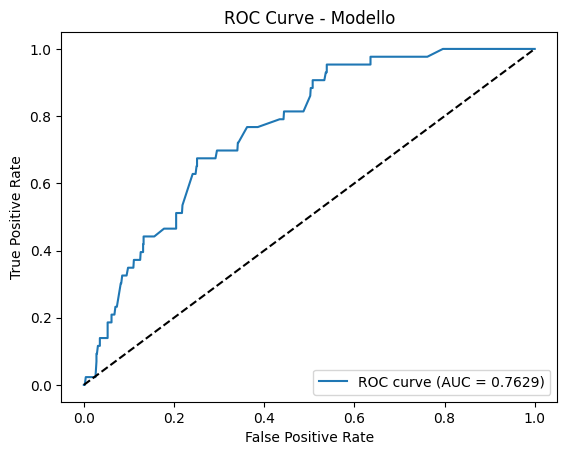

In [9]:
evaluate_on_train_test(gs.best_estimator_, X_train, y_train, X_test, y_test)